Navpreet Kloy, Faith Yang

Dataset: https://www.kaggle.com/datasets/youssefaboelwafa/hotel-booking-cancellation-prediction/data

In [22]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,       # Split data into train/test sets
    cross_val_score         # Cross-validation for robust evaluation
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [23]:
# load dataset
df = pd.read_csv("booking.csv")
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [24]:
# dataset structure overiew including data types and missing values
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [25]:
# number of unique values in each columnn
df.nunique()

,0
Booking_ID,36285
number of adults,5
number of children,6
number of weekend nights,8
number of week nights,18
type of meal,4
car parking space,2
room type,7
lead time,352
market segment type,5


In [26]:
# display all column names in the dataset
print(df.columns.tolist())

['Booking_ID', 'number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'type of meal', 'car parking space', 'room type', 'lead time', 'market segment type', 'repeated', 'P-C', 'P-not-C', 'average price', 'special requests', 'date of reservation', 'booking status']


In [46]:
# view categorical feauture values counts
for col in df.select_dtypes(include='object').columns:
  if col in  ['Booking_ID', 'date of reservation']:   # exclude booking ID and date of reservation
        continue
  print(df[col].value_counts())
  print()

type of meal
Meal Plan 1     27842
Not Selected     5132
Meal Plan 2      3306
Meal Plan 3         5
Name: count, dtype: int64

room type
Room_Type 1    28138
Room_Type 4     6059
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

market segment type
Online           23221
Offline          10531
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64



In [28]:
# check unique booking status values
print(df['booking status'].unique())

['Not_Canceled' 'Canceled']


In [45]:
# view value counts for selected numerical coloumns
for col in ['number of adults', 'number of children','repeated']:
  print(df[col].value_counts())


number of adults
2    26110
1     7702
3     2318
0      139
4       16
Name: count, dtype: int64
number of children
0     33583
1      1622
2      1058
3        19
9         2
10        1
Name: count, dtype: int64
repeated
0    35355
1      930
Name: count, dtype: int64


In [44]:
# statistical summary of numerical features
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


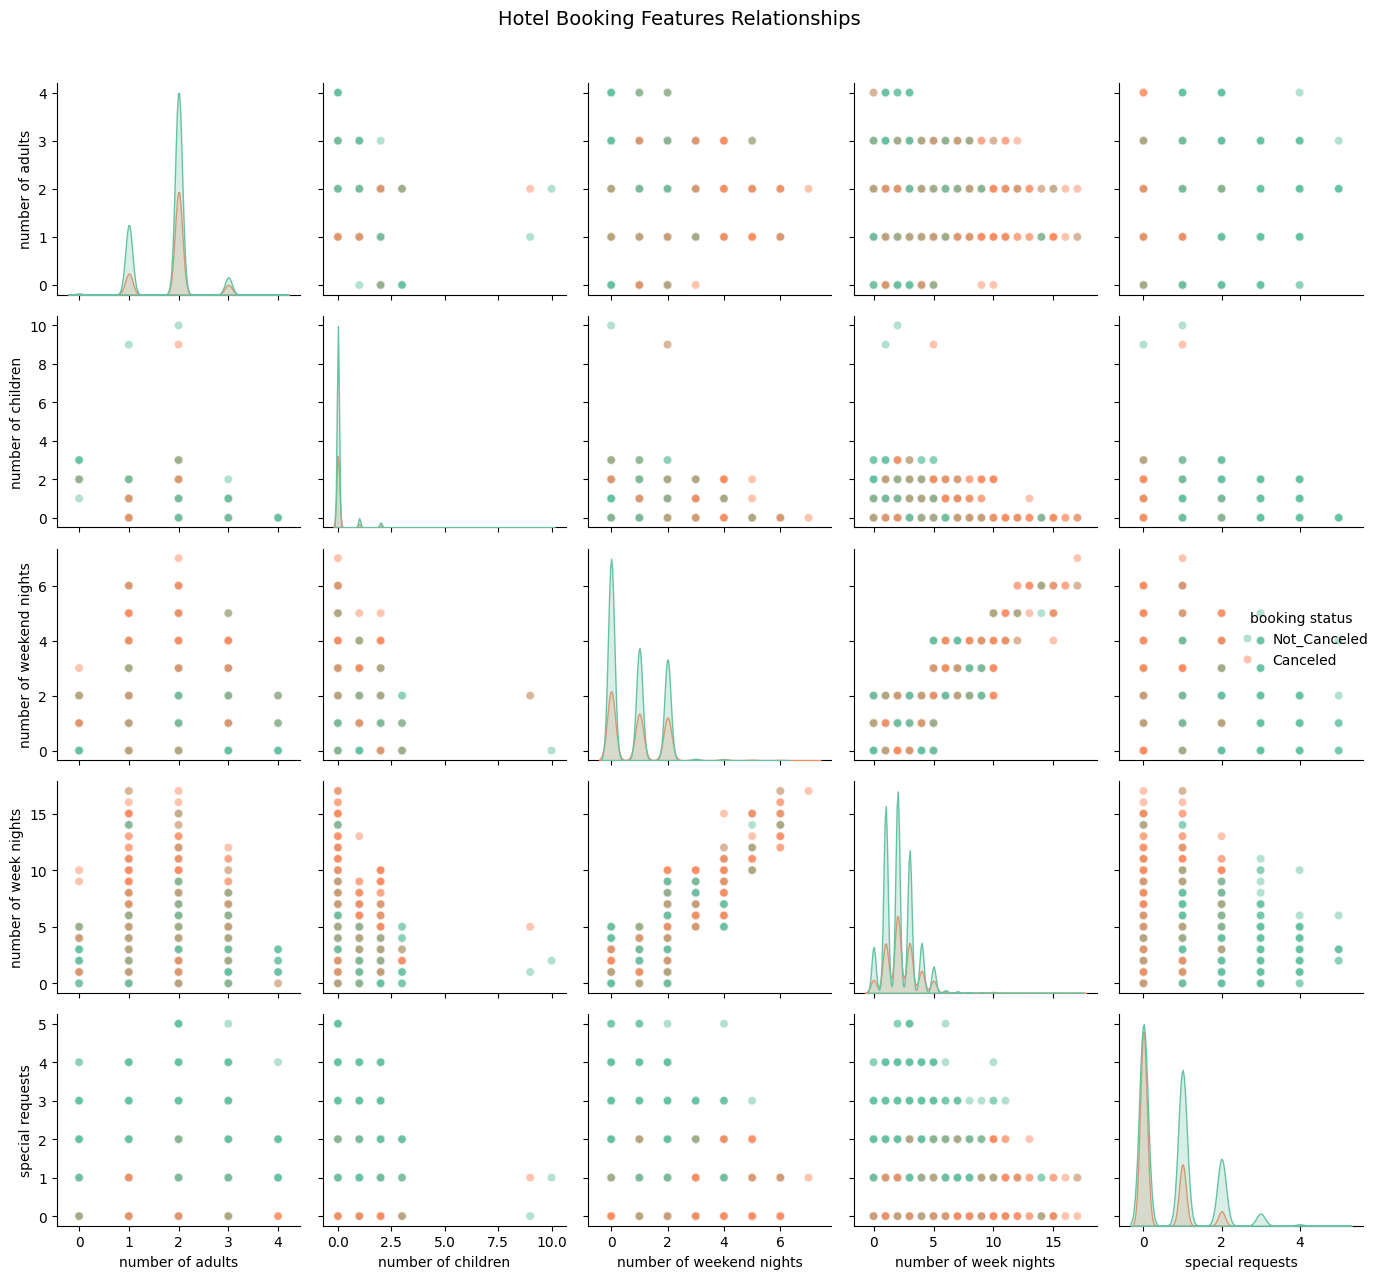

   -> Pair plot saved as 'booking_pairplot.png'
   -> Look for features where the 2 colors separate well.
      Those features will be most useful for KNN!



In [47]:
# --- Pair Plot ---
# We pick features + the label to keep the plot readable
plot_features = ['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'special requests','booking status']

sns.pairplot(
    df[plot_features],         # Only these columns
    hue='booking status',           # Color by booking status
    palette='Set2',            # A nice color palette
    diag_kind='kde',           # Diagonal: show density curves instead of histograms
    plot_kws={                 # Settings for the scatter plots
        'alpha': 0.5,          # Semi-transparent dots
        'edgecolor': 'w'       # White edges around dots
    }
)
plt.suptitle('Hotel Booking Features Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('booking_pairplot.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'booking_pairplot.png'")
print("   -> Look for features where the 2 colors separate well.")
print("      Those features will be most useful for KNN!")
print()


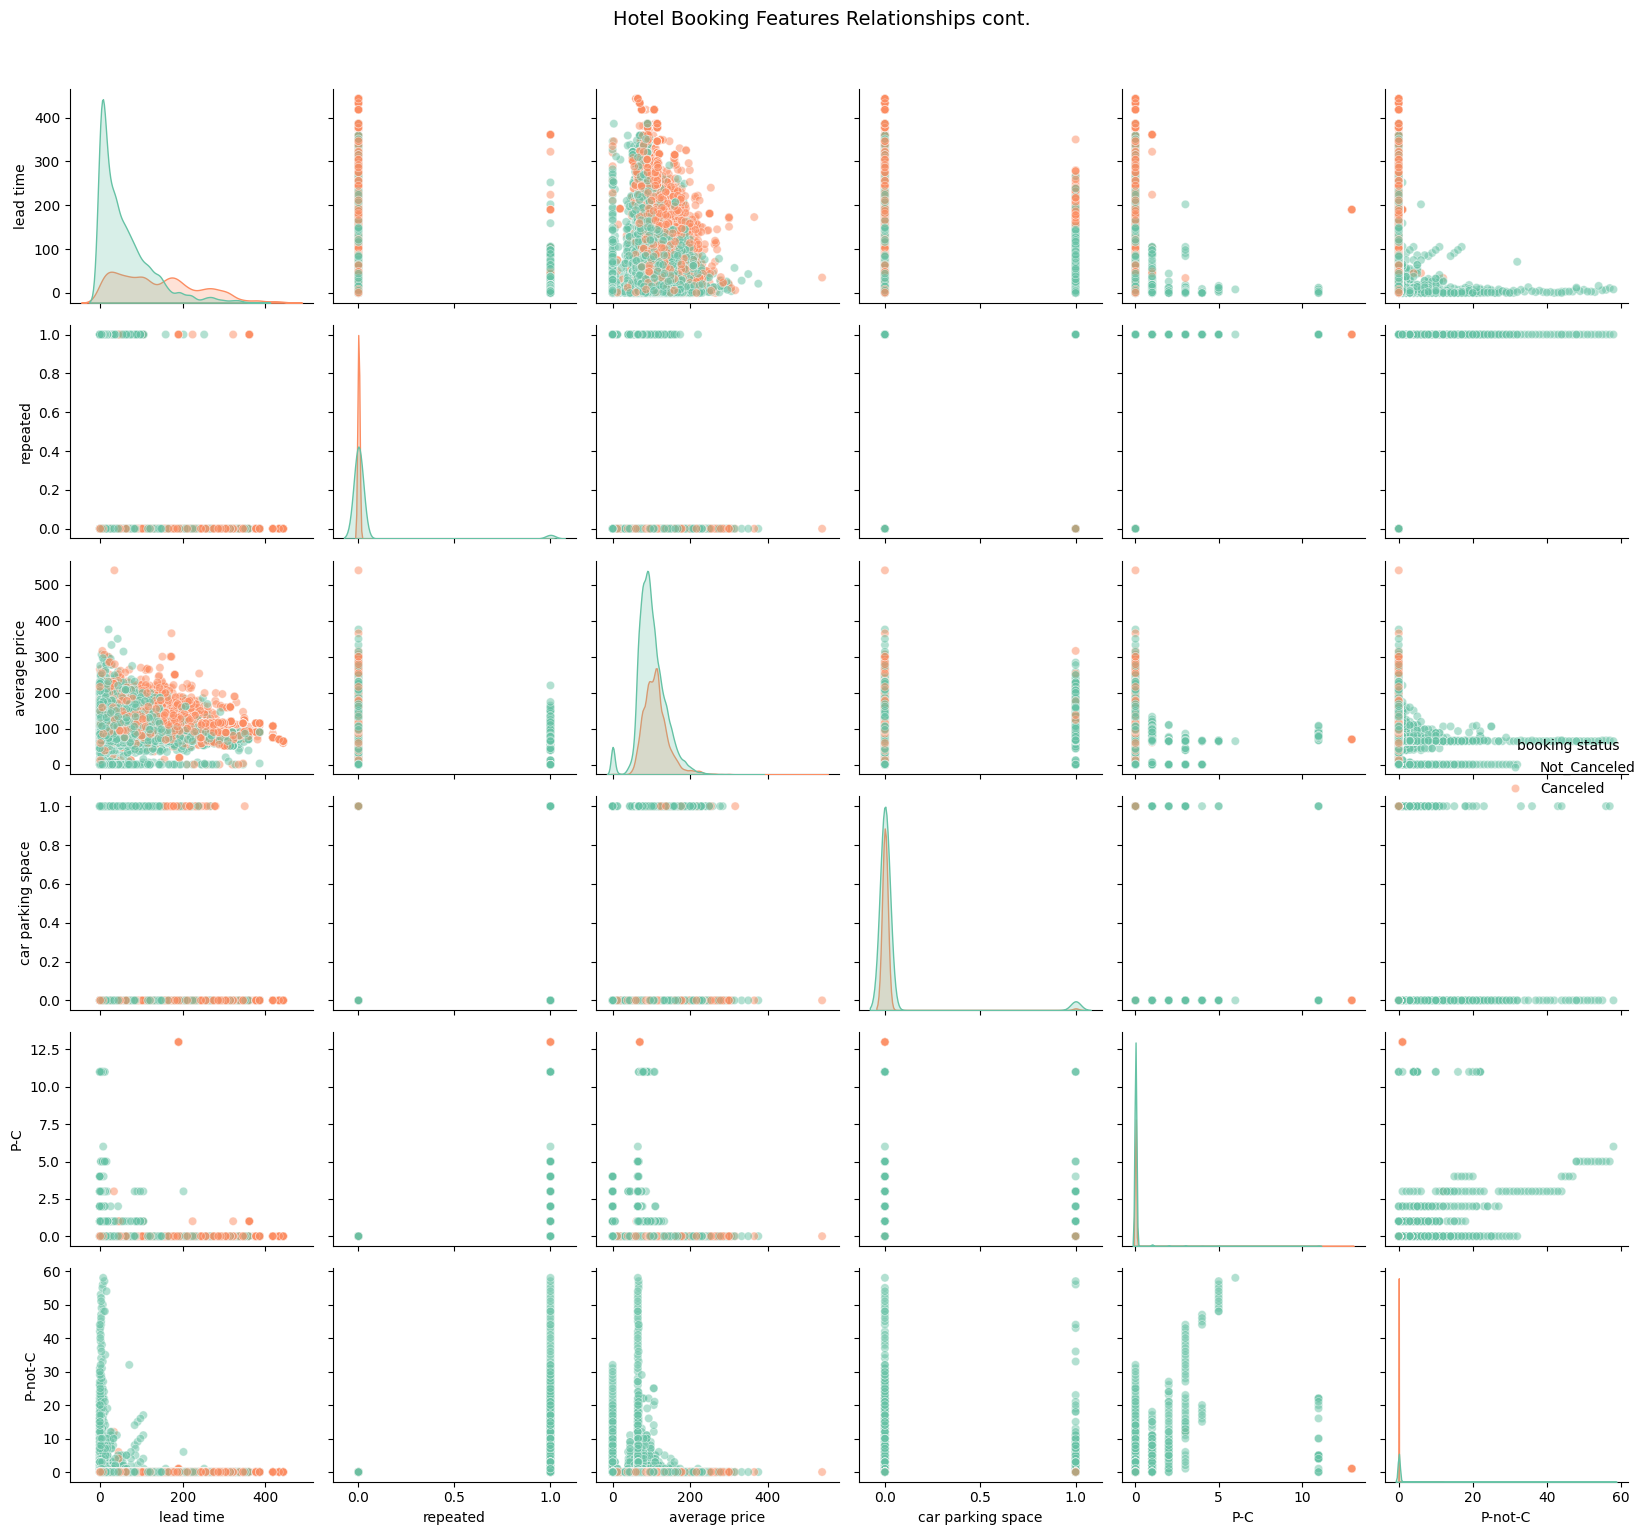

   -> Pair plot saved as 'booking2_pairplot.png'
   -> Look for features where the 2 colors separate well.
      Those features will be most useful for KNN!



In [31]:
# --- Pair Plot ---
# We pick features + the label to keep the plot readable for other selected features
plot_features = ['lead time', 'repeated', 'average price', 'car parking space', 'P-C','P-not-C', 'booking status']

sns.pairplot(
    df[plot_features],         # Only these columns
    hue='booking status',           # Color by booking status
    palette='Set2',            # A nice color palette
    diag_kind='kde',           # Diagonal: show density curves instead of histograms
    plot_kws={                 # Settings for the scatter plots
        'alpha': 0.5,          # Semi-transparent dots
        'edgecolor': 'w'       # White edges around dots
    }
)
plt.suptitle('Hotel Booking Features Relationships cont.', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('booking2_pairplot.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'booking2_pairplot.png'")
print("   -> Look for features where the 2 colors separate well.")
print("      Those features will be most useful for KNN!")
print()


In [32]:
# Separate features from labels
X = df.drop(['Booking_ID', 'date of reservation','booking status'], axis=1)    # Select columns except the label and columns dropped
y = df['booking status']                 # Just the label column


In [33]:
# Split: 80% training, 20% testing
# stratify=y ensures each age group is proportionally represented in both the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")    # number of training samples
print(f"Testing samples:  {X_test.shape[0]}")     # number of testing samples
print()

# Verify the class balance in both sets
print("Class balance check:")
print(f"Training: {dict(pd.Series(y_train).value_counts())}")
print(f"Testing: {dict(pd.Series(y_test).value_counts())}")
print("  (Should be roughly proportional)")
print()


Training samples: 29028
Testing samples:  7257

Class balance check:
Training: {'Not_Canceled': np.int64(19517), 'Canceled': np.int64(9511)}
Testing: {'Not_Canceled': np.int64(4879), 'Canceled': np.int64(2378)}
  (Should be roughly proportional)



In [34]:
# Convert string values to numeric using LabelEncoder

# encode all categorical columns in X
for col in X:
      if X[col].dtype == 'object':
         le = LabelEncoder()
         X_train[col] = le.fit_transform(X_train[col])              #  encode the training data
         X_test[col] = le.transform(X_test[col])                    #  encode the testing data
         mapping = dict(zip(le.classes_, le.transform(le.classes_)))   # create and display mapping of original values to encoded values
         print(col, mapping)


 # view encoded categorical features in testing and training data
print("Encoded Training Data:")
print(X_train.head().to_string(index=False))

print("Encoded Testing Data:")
print(X_test.head().to_string(index=False))

type of meal {'Meal Plan 1': np.int64(0), 'Meal Plan 2': np.int64(1), 'Meal Plan 3': np.int64(2), 'Not Selected': np.int64(3)}
room type {'Room_Type 1': np.int64(0), 'Room_Type 2': np.int64(1), 'Room_Type 3': np.int64(2), 'Room_Type 4': np.int64(3), 'Room_Type 5': np.int64(4), 'Room_Type 6': np.int64(5), 'Room_Type 7': np.int64(6)}
market segment type {'Aviation': np.int64(0), 'Complementary': np.int64(1), 'Corporate': np.int64(2), 'Offline': np.int64(3), 'Online': np.int64(4)}
Encoded Training Data:
 number of adults  number of children  number of weekend nights  number of week nights  type of meal  car parking space  room type  lead time  market segment type  repeated  P-C  P-not-C  average price  special requests
                2                   0                         0                      2             0                  0          0        322                    3         0    0        0          52.00                 0
                2                   0                 

In [35]:
# Scale features using fit_transform on training and transform on testing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Learn + scale
X_test_scaled  = scaler.transform(X_test)         # Scale only (no learning)

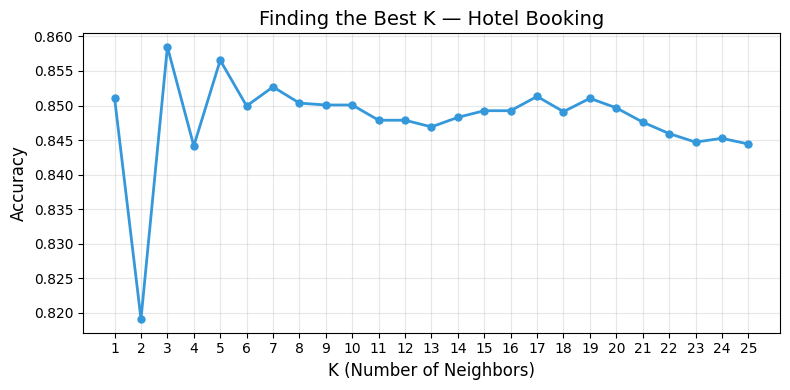

   -> Best K = 3
   -> Best Accuracy = 85.85%
   -> Chart saved as 'booking_best_k.png'



In [36]:
# Find the best value of K for the KNN model, testing every K from 1-25

# Test K values from 1 to 25
k_values = range(1, 26)
accuracies = []  # Create list to store each K's accuracy

# New KNN model is created and trained for each value of K
# Accuracy for each model is stored in the accuracies list
for k in k_values:
    # Create a new model with this K
    model = KNeighborsClassifier(n_neighbors=k)

    # Train it on the same training data
    model.fit(X_train_scaled, y_train)

    # Predict on the test data
    pred = model.predict(X_test_scaled)

    # Calculate accuracy and save it
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

# Plot K vs Accuracy to visualize the performance for each K
plt.figure(figsize=(8, 4))
plt.plot(
    k_values,           # x-axis: K values
    accuracies,         # y-axis: accuracy for each K
    marker='o',         # Circle marker at each point
    color='#3498db',    # Blue color
    linewidth=2,        # Line thickness
    markersize=5        # Marker size
)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Best K — Hotel Booking', fontsize=14)
plt.xticks(k_values)      # Show every K value on x-axis
plt.grid(alpha=0.3)        # Faint grid lines for readability
plt.tight_layout()
plt.savefig('booking_best_k.png', dpi=150)
plt.show()

# Find the K with the highest accuracy
best_k = list(k_values)[np.argmax(accuracies)]  # np.argmax returns the INDEX of the maximum value in accuraciesß list, which maps to the corresponding K value in k_values list
best_accuracy = max(accuracies) # gets and stores the highest accuracy value

print(f"   -> Best K = {best_k}")
print(f"   -> Best Accuracy = {best_accuracy:.2%}")
print(f"   -> Chart saved as 'booking_best_k.png'")
print()

In [37]:
# Build and train the KNN model

# Create a KNN classifier with selected K value
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model on the training data using .fit
knn.fit(X_train_scaled, y_train)

print("Model trained with K=3 neighbors.")
print()

# Make predictions on the test set
# For each test sample, KNN:
#   1. Calculates distance to ALL training samples
#   2. Finds the 3 closest ones
#   3. Takes a majority vote among those 3
y_pred = knn.predict(X_test_scaled)
print("Predictions made on the test set.")


Model trained with K=3 neighbors.

Predictions made on the test set.


Overall Accuracy: 85.85%
Detailed Classification Report:
              precision    recall  f1-score   support

    Canceled       0.79      0.77      0.78      2378
Not_Canceled       0.89      0.90      0.90      4879

    accuracy                           0.86      7257
   macro avg       0.84      0.84      0.84      7257
weighted avg       0.86      0.86      0.86      7257



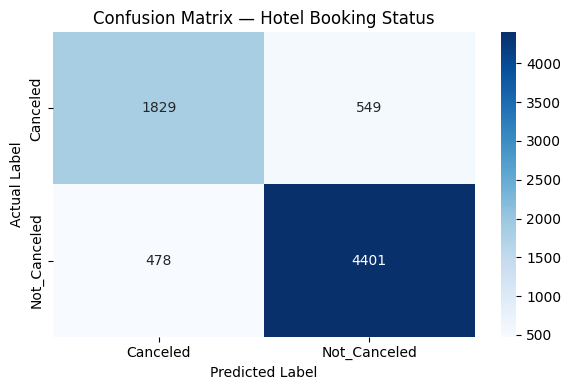

   -> Confusion matrix saved as 'booking_confusion.png'



In [48]:
# Evaluation of KNN model

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

# Detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Displays the following:
#   precision = of all booking that were canceled, how many really were?
#   recall    = of all cancelations, how many did we catch?
#   f1-score  = the harmonic mean of precision and recall
#   support   = how many actual samples of each class were in the test set


# --- Confusion Matrix Heatmap ---
# This visual makes it easy to see where the model gets confused
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,                                        # The confusion matrix data
    annot=True,                                # Show numbers inside cells
    fmt='d',                                   # Format as integers (not decimals)
    cmap='Blues',                               # Blue color scheme
    xticklabels=['Canceled', 'Not_Canceled'],       # Labels for predicted (x-axis)
    yticklabels=['Canceled', 'Not_Canceled']        # Labels for actual (y-axis)
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Hotel Booking Status')
plt.tight_layout()
plt.savefig('booking_confusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'booking_confusion.png'")
print()

In [39]:
# Prepare a provision for a new data entry and its prediction of an outcome.

def predict_cancellation():
    while True:
        try:
            num_adults = int(input("Enter number of adults: "))
            num_children = int(input("Enter number of children: "))
            num_weekend_nights = int(input("Enter number of weekend nights: "))
            num_week_nights = int(input("Enter number of week nights: "))
            meal_type = int(input("Enter type of meal plan (Meal Plan 1: 0, Meal Plan 2: 1, Meal Plan 3: 2, Not Selected: 3): "))
            has_parking = int(input("Enter whether whether a car parking space was requested or included in the booking (No: 0 or Yes: 1): "))
            room_type = int(input("Enter type of room booked (Room Type 1: 0 , Room Type 2: 1, Room Type 3: 2, Room Type 4: 3, Room Type 5: 4, Room Type 6: 5, Room Type 7: 6): "))
            lead_time = int(input("Enter number of days between the booking date and the arrival date (lead time): "))
            market_segment = int(input("Enter type of market segment associated with the booking (Aviation: 0, Complementary: 1, Corporate: 2, Offline: 3, Online: 4): "))
            repeat_booking = int(input("Enter whether the booking is a repeat booking (No: 0 or Yes: 1): "))
            p_c = int(input("Enter number of previous bookings that were canceled by the customer prior to the current booking): "))
            p_not_c = int(input("Enter number of previous bookings not canceled by the customer prior to the current booking: "))
            avg_price = float(input("Enter average price associated with the booking: "))
            special_requests = int(input("Enter number of special requests made by the guest: "))


            # input validation for non-negative values
            if any(val < 0 for val in [num_adults, num_children, num_weekend_nights, num_week_nights, lead_time, p_c, p_not_c, avg_price, special_requests ]):
              print("Error: Please enter non-negative value.")
              continue  #restart the loop

            # input validation for binary variables (0 = No or 1 = Yes)
            if any(val not in [0,1] for val in [has_parking, repeat_booking]):
              print("Error: Please enter 0 or 1.")
              continue  #restart the loop

            # input validation for encoded meal type plan values (0–3)
            if meal_type not in [0,1,2,3]:
              print("Error: Please enter corresponding values between 0 and 3 for meal type plan.")
              continue  #restart the loop

            # input validation for encoded room type values (0–6)
            if room_type not in [0,1,2,3,4,5,6]:
              print("Error: Please enter corresponding values between 0 and 6 for room type.")
              continue  #restart the loop

            # input validation for encoded market segment type (0–4)
            if market_segment not in [0,1,2,3,4]:
              print("Error: Please enter corresponding values between 0 and 4 for market segment.")
              continue  #restart the loop

            # create new customer dataframe from user input
            new_customer_data = pd.DataFrame([[num_adults, num_children, num_weekend_nights, num_week_nights, meal_type, has_parking, room_type, lead_time, market_segment, repeat_booking, p_c, p_not_c, avg_price, special_requests]],
                                           columns=['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'type of meal', 'car parking space', 'room type', 'lead time', 'market segment type', 'repeated', 'P-C', 'P-not-C', 'average price', 'special requests'])

            # Scale the new customer data using the SAME scaler from training
            new_customer_data_scaled = scaler.transform(new_customer_data)

            # Make prediction
            prediction =knn.predict(new_customer_data_scaled)[0]

            if prediction == 'Canceled':
                print("Prediction: Customer is likely to cancel the hotel booking.")
            else:
                print("Prediction: Customer is not likely to cancel the hotel booking.")

            another_customer = input("Enter data for another customer? (yes/no): ")
            if another_customer.lower() != 'yes':
                break #exit loop
        except ValueError:
            print("Invalid input. Please enter valid numerical values.")

predict_cancellation()

Enter number of adults: 3
Enter number of children: 4
Enter number of weekend nights: 3
Enter number of week nights: 2
Enter type of meal plan (Meal Plan 1: 0, Meal Plan 2: 1, Meal Plan 3: 2, Not Selected: 3): 1
Enter whether whether a car parking space was requested or included in the booking (No: 0 or Yes: 1): 0
Enter type of room booked (Room Type 1: 0 , Room Type 2: 1, Room Type 3: 2, Room Type 4: 3, Room Type 5: 4, Room Type 6: 5, Room Type 7: 6): 3
Enter number of days between the booking date and the arrival date (lead time): 43
Enter type of market segment associated with the booking (Aviation: 0, Complementary: 1, Corporate: 2, Offline: 3, Online: 4): 3
Enter whether the booking is a repeat booking (No: 0 or Yes: 1): 0
Enter number of previous bookings that were canceled by the customer prior to the current booking): 45
Enter number of previous bookings not canceled by the customer prior to the current booking: 34
Enter average price associated with the booking: 400
Enter numb

The Hotel Booking Cancellation Prediction dataset was used to build a predictive model to determine whether a customer is likely to cancel their booking or not. A K-Nearest Neighbors (KNN) model was used, which classifies datapoints based on their proximity to each other, grouping similar data points together. The data set contained a total of 36,285 data points and 17 features. The features included booking details (number of nights, number of guests, and room type), booking-related statistics (lead time and average price), and customer history (number of previous cancellations and repeat bookings) for each booking. 14 features were selected as the predictors for the booking status outcome. The features and the target variable were processed and the KNN model was built. The model has an accuracy of 85.85%, meaning 85.85% of were correct, matching the actual booking outcome. The model was better at predicting no cancellations over cancellations.  It correctly predicted 90% of the no cancellation outcomes versus 77% of cancellations of all the cancellation outcomes. Similarly, the model had greater precision in no cancellations outcomes, it was correct 89% of the time when no cancellations were predicted. The precision for cancellation was 79%. The F1- score, representing the balance of above, again highlights strong performance in no cancellations (0.90) compared to cancellations (0.78). The confusion matrix, which displays the number of true positive and false positive counts for both the outcomes. In this case, the number of false positives for both outcomes are almost balanced. Overall, despite the model having stronger performance in predicting no cancellation outcomes, the average metrics indicate the model’s overall performance is strong.
